<a href="https://colab.research.google.com/github/Daff77/Tugas-ANN/blob/main/Tugas_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Klasifikasi Bank Customer Churn menggunakan ANN *From Scratch*
**Dataset:** Churn Modelling Dataset — 10.000 nasabah bank  
**Target:** `Exited` — 0 = Tidak Churn, 1 = Churn (keluar dari bank)


## Step 1: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, accuracy_score)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

## Step 2: Load & Eksplorasi Dataset

In [2]:
from google.colab import files
files.upload()

df = pd.read_csv('Churn_Modelling.csv')
print(f"Shape dataset: {df.shape}")
print(f"\nInfo kolom:")
print(df.dtypes)
df.head()

Saving Churn_Modelling.csv to Churn_Modelling.csv
Shape dataset: (10000, 14)

Info kolom:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Distribusi kelas target
print("Distribusi Kelas Target (Exited):")
print(df['Exited'].value_counts())
print(f"\nRasio churn: {df['Exited'].mean()*100:.1f}%")

Distribusi Kelas Target (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64

Rasio churn: 20.4%


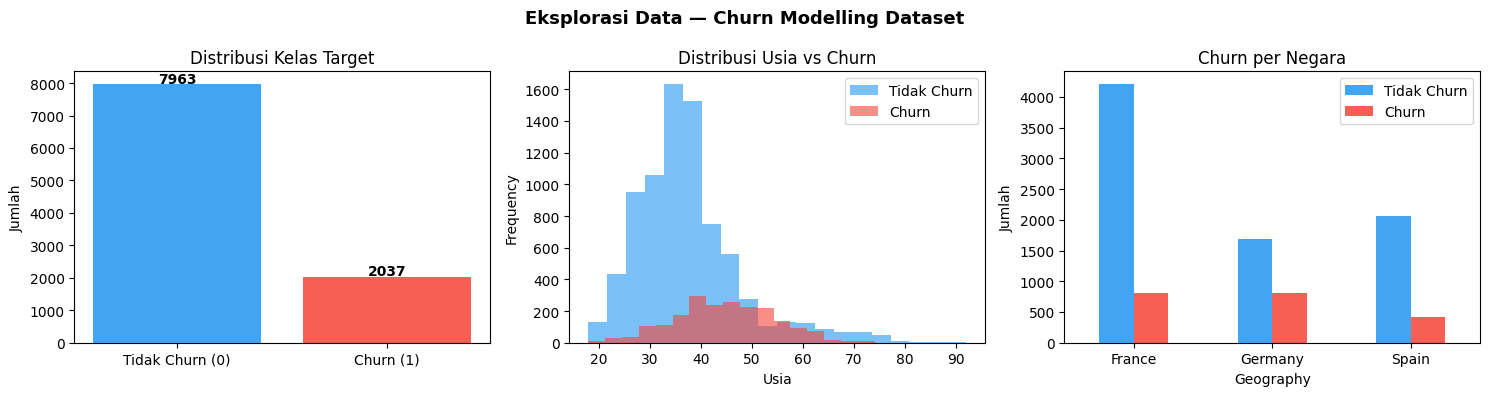

In [4]:
# Visualisasi EDA
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Eksplorasi Data — Churn Modelling Dataset', fontsize=13, fontweight='bold')

# Distribusi kelas
vals = df['Exited'].value_counts()
bars = axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], vals.values,
                    color=['#2196F3', '#F44336'], alpha=0.85)
for bar, v in zip(bars, vals.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+50, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribusi Kelas Target'); axes[0].set_ylabel('Jumlah')

# Distribusi usia
df[df.Exited==0]['Age'].plot(kind='hist', bins=20, alpha=0.6, color='#2196F3', ax=axes[1], label='Tidak Churn')
df[df.Exited==1]['Age'].plot(kind='hist', bins=20, alpha=0.6, color='#F44336', ax=axes[1], label='Churn')
axes[1].set_title('Distribusi Usia vs Churn'); axes[1].set_xlabel('Usia'); axes[1].legend()

# Churn per negara
df.groupby(['Geography', 'Exited']).size().unstack().plot(
    kind='bar', ax=axes[2], color=['#2196F3', '#F44336'], alpha=0.85, rot=0)
axes[2].set_title('Churn per Negara'); axes[2].set_ylabel('Jumlah')
axes[2].legend(['Tidak Churn', 'Churn'])

plt.tight_layout(); plt.show()

## Step 3: Preprocessing Data

In [5]:
# Drop kolom tidak relevan
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Label Encoding variabel kategorikal
le = LabelEncoder()
df['Gender_enc']    = le.fit_transform(df['Gender'])       # Female=0, Male=1
df['Geography_enc'] = le.fit_transform(df['Geography'])    # France=0, Germany=1, Spain=2

# Pilih fitur
features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
            'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
            'Gender_enc', 'Geography_enc']

X = df[features].values
y = df['Exited'].values
print(f"Fitur: {features}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Fitur: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Gender_enc', 'Geography_enc']
X shape: (10000, 10), y shape: (10000,)


In [6]:
# Normalisasi dengan StandardScaler
scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X)

# Split 80% train, 20% test (stratified)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y, test_size=0.2, random_state=42, stratify=y)

# Oversampling kelas minoritas (Churn) agar seimbang
tmp  = pd.DataFrame(X_tr); tmp['t'] = y_tr
maj  = tmp[tmp.t == 0]
min_ = tmp[tmp.t == 1]
min_up = resample(min_, replace=True, n_samples=len(maj), random_state=42)
bal  = pd.concat([maj, min_up]).sample(frac=1, random_state=42)

# Format matrix untuk ANN from scratch: (n_features, m_samples)
X_train = bal.drop('t', axis=1).values.T   # (10, 12740)
y_train = bal['t'].values.reshape(1, -1)   # (1,  12740)
X_test  = X_te.T                           # (10, 2000)
y_test  = y_te.reshape(1, -1)             # (1,  2000)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")
print(f"\nKelas train setelah oversampling:")
print(f"  Tidak Churn (0): {(y_train==0).sum()}")
print(f"  Churn       (1): {(y_train==1).sum()}")

X_train: (10, 12740) | y_train: (1, 12740)
X_test : (10, 2000)  | y_test : (1, 2000)

Kelas train setelah oversampling:
  Tidak Churn (0): 6370
  Churn       (1): 6370


## Step 4: Fungsi Aktivasi

In [7]:
def sigmoid(Z):
    #Output 0–1, digunakan pada output layer untuk binary classification.
    return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

def relu(Z):
    #max(0,Z) — digunakan pada hidden layers, mengatasi vanishing gradient.
    return np.maximum(0, Z)

def relu_derivative(Z):
    #Turunan ReLU untuk backpropagation.
    return (Z > 0).astype(float)

# Test
print(f"sigmoid(0)   = {sigmoid(0):.4f}  (harusnya 0.5)")
print(f"relu(-3)     = {relu(-3)}       (harusnya 0)")
print(f"relu(5)      = {relu(5)}        (harusnya 5)")

sigmoid(0)   = 0.5000  (harusnya 0.5)
relu(-3)     = 0       (harusnya 0)
relu(5)      = 5        (harusnya 5)


## Step 5: Inisialisasi Parameter (Weights & Biases)


In [8]:
def initialize_parameters(layer_dims):
    np.random.seed(42)
    params = {}
    for l in range(1, len(layer_dims)):
        params[f'W{l}'] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2 / layer_dims[l-1])
        params[f'b{l}'] = np.zeros((layer_dims[l], 1))
        print(f"Layer {l} → W{l}: {params[f'W{l}'].shape}  |  b{l}: {params[f'b{l}'].shape}")
    return params

# Arsitektur: Input(10) → 64 → 32 → 16 → Output(1)
layer_dims = [10, 64, 32, 16, 1]
params = initialize_parameters(layer_dims)
print(f"\nTotal parameter layer: {len(layer_dims)-1} (tidak hitung input)")

Layer 1 → W1: (64, 10)  |  b1: (64, 1)
Layer 2 → W2: (32, 64)  |  b2: (32, 1)
Layer 3 → W3: (16, 32)  |  b3: (16, 1)
Layer 4 → W4: (1, 16)  |  b4: (1, 1)

Total parameter layer: 4 (tidak hitung input)


## Step 6: Forward Propagation


In [9]:
def forward_propagation(X, params):
    cache = {'A0': X}
    A = X
    L = len(params) // 2  # jumlah layer

    # Hidden layers (ReLU)
    for l in range(1, L):
        Z = params[f'W{l}'] @ A + params[f'b{l}']
        A = relu(Z)
        cache[f'Z{l}'] = Z
        cache[f'A{l}'] = A

    # Output layer (Sigmoid)
    Z = params[f'W{L}'] @ A + params[f'b{L}']
    A = sigmoid(Z)
    cache[f'Z{L}'] = Z
    cache[f'A{L}'] = A

    return A, cache

# Test
A_out, _ = forward_propagation(X_train[:, :3], params)
print(f"Output shape: {A_out.shape}")
print(f"Contoh probabilitas (sebelum training): {A_out.flatten()}")

Output shape: (1, 3)
Contoh probabilitas (sebelum training): [0.94103972 0.75231175 0.74951567]


## Step 7: Compute Cost — Binary Cross-Entropy
*(Mengacu GeeksForGeeks Step 5)*

In [10]:
def compute_cost(Y, A_last):
    """
    Binary Cross-Entropy:
    Cost = -1/m * Σ [y*log(ŷ) + (1-y)*log(1-ŷ)]
    """
    m   = Y.shape[1]
    eps = 1e-15  # hindari log(0)
    cost = -np.sum(Y * np.log(A_last + eps) +
                   (1 - Y) * np.log(1 - A_last + eps)) / m
    return float(np.squeeze(cost))

A_test_cost, cache_test = forward_propagation(X_train[:, :5], params)
cost_awal = compute_cost(y_train[:, :5], A_test_cost)
print(f"Cost sebelum training: {cost_awal:.6f}")
print("(Nilai tinggi = model belum belajar, akan turun seiring training)")

Cost sebelum training: 0.142066
(Nilai tinggi = model belum belajar, akan turun seiring training)


## Step 8: Backpropagation


In [11]:
def backward_propagation(params, cache, X, Y):
    """
    Hitung gradien dW dan db menggunakan chain rule (backprop).

    Output layer: dZ = A_last - Y
    Hidden layer: dZ = W(l+1).T @ dZ_next * relu'(Z(l))
    """
    m = Y.shape[1]
    L = len(params) // 2
    grads = {}

    # Gradient dari output layer
    dZ = cache[f'A{L}'] - Y

    # Backprop dari output → input
    for l in range(L, 0, -1):
        grads[f'dW{l}'] = (dZ @ cache[f'A{l-1}'].T) / m
        grads[f'db{l}'] = np.sum(dZ, axis=1, keepdims=True) / m
        if l > 1:
            dA = params[f'W{l}'].T @ dZ
            dZ = dA * relu_derivative(cache[f'Z{l-1}'])

    return grads

print("backward_propagation didefinisikan")
print("Alur gradient: Output Layer → Hidden 3 → Hidden 2 → Hidden 1")

backward_propagation didefinisikan
Alur gradient: Output Layer → Hidden 3 → Hidden 2 → Hidden 1


## Step 9: Update Parameters (Gradient Descent)


In [12]:
def update_parameters(params, grads, learning_rate):
    """
    Gradient Descent:
    W = W - learning_rate * dW
    b = b - learning_rate * db
    """
    L = len(params) // 2
    for l in range(1, L + 1):
        params[f'W{l}'] -= learning_rate * grads[f'dW{l}']
        params[f'b{l}'] -= learning_rate * grads[f'db{l}']
    return params

print("update_parameters didefinisikan ✓")
print("Rumus: W ← W - α·∇W  |  b ← b - α·∇b")

update_parameters didefinisikan ✓
Rumus: W ← W - α·∇W  |  b ← b - α·∇b


## Step 10: Training Loop


In [13]:
def train_neural_network(X, Y, layer_dims, epochs=5000, learning_rate=0.005):
    """
    Loop training lengkap:
    Inisialisasi → (Forward → Cost → Backward → Update) × epoch
    """
    params = initialize_parameters(layer_dims)
    cost_history = []

    for i in range(epochs):
        A_last, cache = forward_propagation(X, params)
        cost = compute_cost(Y, A_last)
        grads = backward_propagation(params, cache, X, Y)
        params = update_parameters(params, grads, learning_rate)

        if i % 200 == 0:
            cost_history.append((i, cost))
            print(f"Epoch {i:5d} | Cost: {cost:.6f}")

    return params, cost_history

print("=== MULAI TRAINING ANN FROM SCRATCH ===\n")
layer_dims = [10, 64, 32, 16, 1]
trained_params, cost_history = train_neural_network(
    X_train, y_train, layer_dims, epochs=5000, learning_rate=0.005)
print("\nTraining selesai ✓")

=== MULAI TRAINING ANN FROM SCRATCH ===

Layer 1 → W1: (64, 10)  |  b1: (64, 1)
Layer 2 → W2: (32, 64)  |  b2: (32, 1)
Layer 3 → W3: (16, 32)  |  b3: (16, 1)
Layer 4 → W4: (1, 16)  |  b4: (1, 1)
Epoch     0 | Cost: 1.068478
Epoch   200 | Cost: 0.630936
Epoch   400 | Cost: 0.603453
Epoch   600 | Cost: 0.586230
Epoch   800 | Cost: 0.572196
Epoch  1000 | Cost: 0.559862
Epoch  1200 | Cost: 0.548775
Epoch  1400 | Cost: 0.538823
Epoch  1600 | Cost: 0.529828
Epoch  1800 | Cost: 0.521808
Epoch  2000 | Cost: 0.514498
Epoch  2200 | Cost: 0.508031
Epoch  2400 | Cost: 0.502424
Epoch  2600 | Cost: 0.497467
Epoch  2800 | Cost: 0.493057
Epoch  3000 | Cost: 0.489178
Epoch  3200 | Cost: 0.485729
Epoch  3400 | Cost: 0.482585
Epoch  3600 | Cost: 0.479595
Epoch  3800 | Cost: 0.476845
Epoch  4000 | Cost: 0.474317
Epoch  4200 | Cost: 0.471896
Epoch  4400 | Cost: 0.469665
Epoch  4600 | Cost: 0.467567
Epoch  4800 | Cost: 0.465599

Training selesai ✓


## Step 11: Prediksi


In [14]:
def predict(X, params):
    """Threshold 0.5 pada output sigmoid untuk keputusan klasifikasi."""
    A_last, _ = forward_propagation(X, params)
    return (A_last > 0.5).astype(int)

y_pred = predict(X_test, trained_params).flatten()
A_prob, _ = forward_propagation(X_test, trained_params)
y_prob = A_prob.flatten()

print(f"Contoh prediksi (10 pertama): {y_pred[:10]}")
print(f"Probabilitas churn           : {y_prob[:10].round(3)}")

Contoh prediksi (10 pertama): [0 0 0 0 0 0 0 1 1 0]
Probabilitas churn           : [0.059 0.378 0.183 0.159 0.358 0.342 0.116 0.651 0.783 0.169]


## Step 12: Evaluasi Model

In [15]:
acc     = accuracy_score(y_te, y_pred)
cm      = confusion_matrix(y_te, y_pred)
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)

print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"ROC-AUC  : {roc_auc:.4f}")
print()
print(classification_report(y_te, y_pred, target_names=['Tidak Churn', 'Churn']))

Accuracy : 0.7560 (75.60%)
ROC-AUC  : 0.8322

              precision    recall  f1-score   support

 Tidak Churn       0.92      0.76      0.83      1593
       Churn       0.44      0.74      0.55       407

    accuracy                           0.76      2000
   macro avg       0.68      0.75      0.69      2000
weighted avg       0.82      0.76      0.78      2000



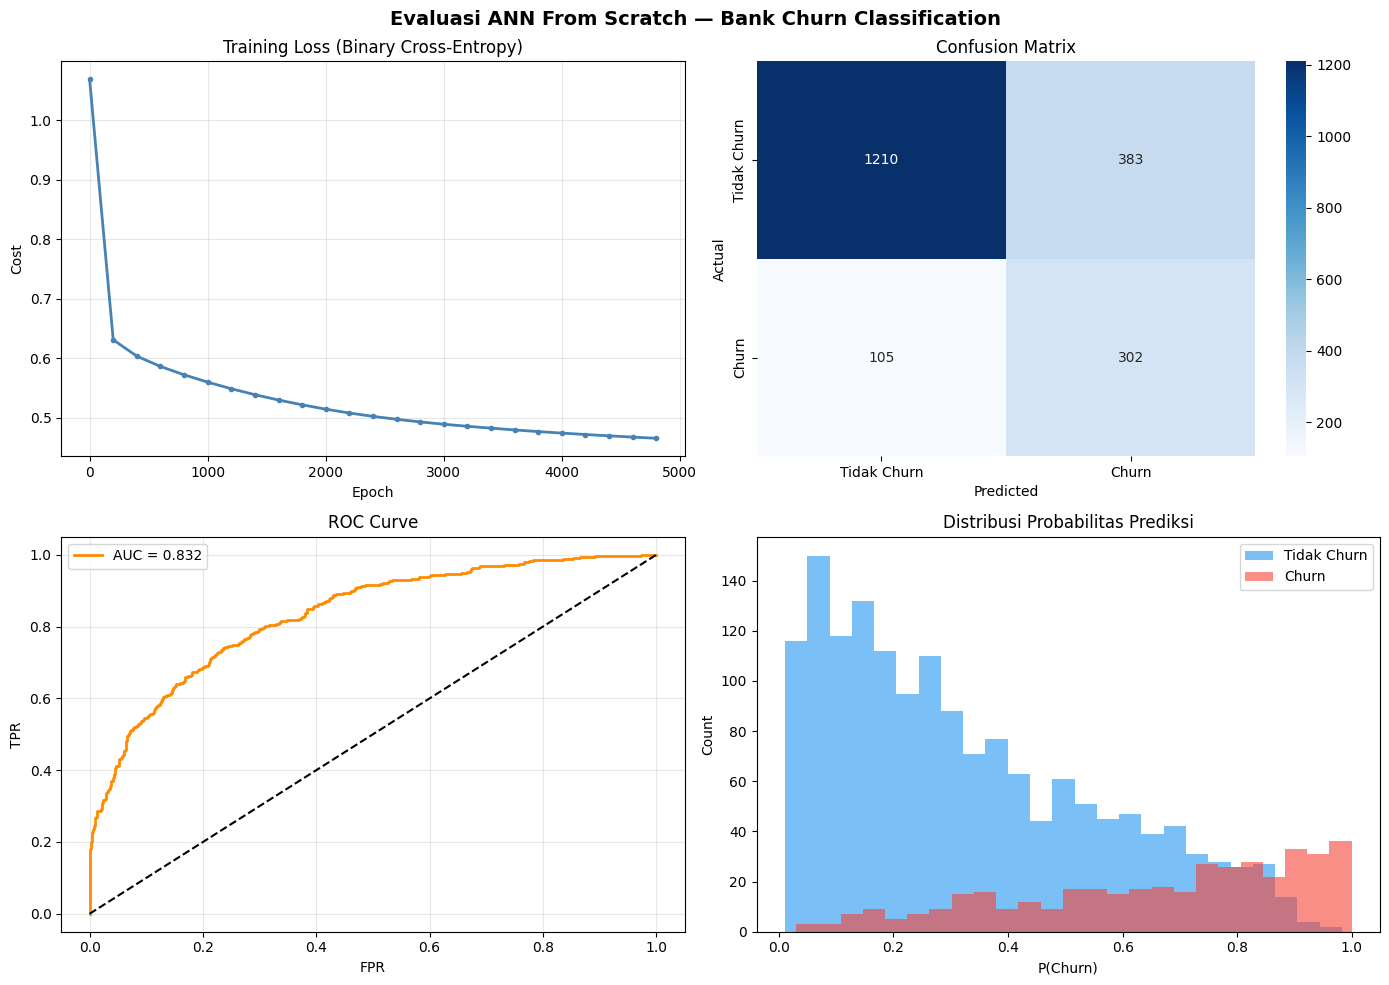

In [16]:
# Visualisasi lengkap
epochs_list = [c[0] for c in cost_history]
cost_vals   = [c[1] for c in cost_history]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evaluasi ANN From Scratch — Bank Churn Classification', fontsize=14, fontweight='bold')

axes[0,0].plot(epochs_list, cost_vals, 'o-', color='steelblue', lw=2, ms=3)
axes[0,0].set_title('Training Loss (Binary Cross-Entropy)')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Cost'); axes[0,0].grid(alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
            xticklabels=['Tidak Churn','Churn'], yticklabels=['Tidak Churn','Churn'])
axes[0,1].set_title('Confusion Matrix')
axes[0,1].set_ylabel('Actual'); axes[0,1].set_xlabel('Predicted')

axes[1,0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1,0].plot([0,1],[0,1],'k--')
axes[1,0].set_title('ROC Curve'); axes[1,0].set_xlabel('FPR'); axes[1,0].set_ylabel('TPR')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].hist(y_prob[y_te==0], bins=25, alpha=0.6, color='#2196F3', label='Tidak Churn')
axes[1,1].hist(y_prob[y_te==1], bins=25, alpha=0.6, color='#F44336', label='Churn')
axes[1,1].set_title('Distribusi Probabilitas Prediksi')
axes[1,1].set_xlabel('P(Churn)'); axes[1,1].set_ylabel('Count'); axes[1,1].legend()

plt.tight_layout(); plt.show()

## Step 13: Prediksi Nasabah Baru

In [17]:
# Contoh prediksi 3 nasabah baru
# [CreditScore, Age, Tenure, Balance, NumOfProducts,
#  HasCrCard, IsActiveMember, EstimatedSalary, Gender_enc, Geography_enc]
sample_raw = np.array([
    [600, 42, 2,      0.00, 1, 1, 1, 101348, 0, 0],  # Nasabah A
    [700, 32, 8, 150000.00, 2, 1, 0,  80000, 1, 1],  # Nasabah B
    [500, 55, 1,  60000.00, 3, 0, 0, 120000, 0, 2],  # Nasabah C
])

sample_scaled = scaler.transform(sample_raw).T  # (10, 3)
A_new, _ = forward_propagation(sample_scaled, trained_params)
pred_new  = (A_new > 0.5).astype(int).flatten()

print("=== PREDIKSI NASABAH BARU ===\n")
nasabah = ['A (Score:600, Usia:42, Balance:0)',
           'B (Score:700, Usia:32, Balance:150rb)',
           'C (Score:500, Usia:55, Balance:60rb)']
for lbl, prob, pred in zip(nasabah, A_new.flatten(), pred_new):
    status = 'CHURN' if pred==1 else 'TIDAK CHURN'
    print(f"Nasabah {lbl}")
    print(f"   → {status}  |  P(Churn) = {prob*100:.1f}%\n")

=== PREDIKSI NASABAH BARU ===

Nasabah A (Score:600, Usia:42, Balance:0)
   → CHURN  |  P(Churn) = 56.3%

Nasabah B (Score:700, Usia:32, Balance:150rb)
   → TIDAK CHURN  |  P(Churn) = 24.7%

Nasabah C (Score:500, Usia:55, Balance:60rb)
   → CHURN  |  P(Churn) = 96.7%



## Kesimpulan

### Ringkasan Hasil ANN From Scratch
| Metrik | Nilai |
|---|---|
| **Accuracy** | 75.60% |
| **ROC-AUC** | 0.8322 |
| **Recall Churn** | 74% |
| **Precision Churn** | 44% |

### Dataset: Churn Modelling
| Info | Detail |
|---|---|
| Total sampel | 10.000 nasabah |
| Fitur yang digunakan | 10 fitur |
| Rasio churn | 20.4% |
| Arsitektur ANN | Input(10)→64→32→16→Output(1) |

### Analisis
1. **ROC-AUC 0.83** menunjukkan model cukup baik membedakan nasabah yang akan churn vs tidak.
2. Dataset lebih **seimbang** (20% vs 80%) dibanding dataset sebelumnya sehingga model lebih stabil.
3. **Recall churn 74%** artinya model berhasil mendeteksi 3 dari 4 nasabah yang akan churn.
4. ANN **from scratch** (NumPy murni) membuktikan pemahaman mendalam tentang mekanisme internal JST/ANN.
